# Estimação por Máxima Verossimilhança

- **Disciplina:** Inteligência Computacional / Métodos Computacionais
- **Docente:** Prof. Felipe Proença de Albuquerque
- **Discente:** João Victor Nogueira de Souza

---

## 1 - Maximização da função de verossimilhança

Seja uma amostra aleatória

$$
X_1, X_2, \ldots, X_n \overset{\text{i.i.d.}}{\sim} f(x \mid \theta).
$$

Como as variáveis são independentes, a densidade conjunta fatora. Fixadas as observações medidas, essa
mesma expressão passa a ser lida como função de $\theta$ e recebe o nome de **função de
verossimilhança**:

$$
L(\theta) = f_{\mathbf{X}}(\mathbf{x} \mid \theta) = \prod_{i=1}^{n} f(x_i \mid \theta).
$$

O **estimador de máxima verossimilhança** é o valor do parâmetro que torna a amostra observada a mais
provável possível:

$$
\hat{\theta}_{\mathrm{MV}} = \arg\max_{\theta} \; L(\theta).
$$

Como o produtório é numericamente inconveniente e o logaritmo é estritamente crescente, o ponto de
máximo não se altera ao maximizar a log-verossimilhança, com a vantagem de converter o produto em soma:

$$
\ell(\theta) = \ln L(\theta) = \sum_{i=1}^{n} \ln f(x_i \mid \theta).
$$

Nos casos regulares o máximo é interior e diferenciável, de modo que $\hat{\theta}_{\mathrm{MV}}$
satisfaz a **equação de verossimilhança**

$$
\left. \frac{\partial \ell(\theta)}{\partial \theta} \right|_{\theta = \hat{\theta}_{\mathrm{MV}}} = 0,
\qquad
\left. \frac{\partial^2 \ell(\theta)}{\partial \theta^2} \right|_{\theta = \hat{\theta}_{\mathrm{MV}}} < 0 .
$$

Com mais de um parâmetro, $\theta = (\theta_1, \ldots, \theta_p)$, a condição vira um sistema: anulam-se
simultaneamente todas as derivadas parciais $\partial \ell / \partial \theta_j = 0$.

O estimador é função da amostra aleatória, logo é ele próprio uma variável aleatória, e vale a
avaliação da Aula 3: $b(\theta) = \mathbb{E}[\hat{\theta}] - \theta$ e

$$
\mathrm{EQM}(\hat{\theta}) = \mathbb{E}\!\left[ (\hat{\theta} - \theta)^2 \right]
= b(\theta)^2 + \operatorname{Var}(\hat{\theta}).
$$

Sob condições de regularidade, o estimador de máxima verossimilhança é consistente, é assintoticamente
não viesado, de modo que as duas parcelas do EQM tendem a zero com o crescimento da amostra, e é
invariante: se $\hat{\theta}$ é o MV de $\theta$, então $g(\hat{\theta})$ é o MV de $g(\theta)$.

---

## 2 - Exemplo: variáveis aleatórias i.i.d. Gaussianas

Seja $X_1, \ldots, X_n \overset{\text{i.i.d.}}{\sim} \mathcal{N}(\mu, \sigma^2)$, com os dois parâmetros
desconhecidos, $\theta_1 = \mu$ e $\theta_2 = \sigma$. Pela independência,

$$
L(\theta_1, \theta_2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\,\theta_2}
\exp\!\left( -\frac{(x_i - \theta_1)^2}{2\theta_2^{2}} \right)
= \frac{1}{(2\pi)^{n/2} \theta_2^{\,n}}
\exp\!\left( -\frac{1}{2\theta_2^{2}} \sum_{i=1}^{n} (x_i - \theta_1)^2 \right),
$$

$$
\ell(\theta_1, \theta_2)
= -\frac{n}{2}\ln(2\pi) - n \ln \theta_2 - \frac{1}{2\theta_2^{2}} \sum_{i=1}^{n} (x_i - \theta_1)^2 .
$$

**Estimador de $\mu$.** Derivando em relação a $\theta_1$,

$$
\frac{\partial \ell}{\partial \theta_1}
= \frac{1}{\theta_2^{2}} \sum_{i=1}^{n} (x_i - \theta_1) = 0
\quad \Longrightarrow \quad
\sum_{i=1}^{n} x_i - n\theta_1 = 0
\quad \Longrightarrow \quad
\boxed{\;\hat{\mu}_{\mathrm{MV}} = \bar{X}\;}
$$

**Estimador de $\sigma$.** Derivando em relação a $\theta_2$,

$$
\frac{\partial \ell}{\partial \theta_2}
= -\frac{n}{\theta_2} + \frac{1}{\theta_2^{3}} \sum_{i=1}^{n} (x_i - \theta_1)^2 = 0 .
$$

Multiplicando por $\theta_2^{3}$ e substituindo $\hat{\theta}_1 = \bar{x}$,

$$
\boxed{\;\hat{\sigma}^2_{\mathrm{MV}} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2\;}
$$

com denominador $n$, e não $n-1$: o estimador de máxima verossimilhança da variância é viesado.

### 2.1 - Viés, variância e EQM

**Estimador da média.** Pela linearidade da esperança e pela independência,

$$
\mathbb{E}[\hat{\mu}] = \frac{1}{n} \sum_{i=1}^{n} \mathbb{E}[X_i] = \mu,
\qquad
\operatorname{Var}(\hat{\mu}) = \frac{1}{n^2} \sum_{i=1}^{n} \operatorname{Var}(X_i) = \frac{\sigma^2}{n},
$$

logo $b(\mu) = 0$ e $\mathrm{EQM}(\hat{\mu}) = \sigma^2/n$.

**Estimador da variância.** Escrevendo
$\sum_i (X_i - \bar{X})^2 = \sum_i X_i^2 - n\bar{X}^2$ e usando
$\operatorname{Var}(W) = \mathbb{E}[W^2] - \mathbb{E}[W]^2$ da Aula 1 nas duas parcelas,

$$
\mathbb{E}\!\left[ \sum_{i=1}^{n} X_i^2 \right] = n(\sigma^2 + \mu^2),
\qquad
\mathbb{E}\!\left[ \bar{X}^2 \right] = \frac{\sigma^2}{n} + \mu^2,
$$

$$
\mathbb{E}\!\left[ \sum_{i=1}^{n} (X_i - \bar{X})^2 \right]
= n(\sigma^2 + \mu^2) - n\left( \frac{\sigma^2}{n} + \mu^2 \right)
= (n-1)\sigma^2 .
$$

Portanto $\mathbb{E}[\hat{\sigma}^2_{\mathrm{MV}}] = \frac{n-1}{n}\sigma^2$ e
$b(\sigma^2) = -\sigma^2/n$: o estimador subestima a variância, e o viés desaparece quando $n$ cresce.
Para a variância do estimador vale, em população Gaussiana, o resultado adotado no notebook do
professor,

$$
\operatorname{Var}\!\left( \hat{\sigma}^2_{\mathrm{MV}} \right) = \frac{2(n-1)}{n^2}\sigma^4
\qquad \Longrightarrow \qquad
\mathrm{EQM}\!\left( \hat{\sigma}^2_{\mathrm{MV}} \right) = \frac{2n-1}{n^2}\sigma^4 .
$$

**Valores para o experimento.** Com $\mu = 50$, $\sigma^2 = 4$ e $n = 100$:

$$
\operatorname{Var}(\hat{\mu}) = \frac{4}{100} = 0{,}04,
\qquad
\mathbb{E}[\hat{\sigma}^2_{\mathrm{MV}}] = \frac{99}{100}\cdot 4 = 3{,}96,
\qquad
b = -0{,}04,
$$

$$
\operatorname{Var}(\hat{\sigma}^2_{\mathrm{MV}}) = \frac{2 \cdot 99}{10^4}\cdot 16 = 0{,}3168,
\qquad
\mathrm{EQM}(\hat{\sigma}^2_{\mathrm{MV}}) = \frac{199}{10^4}\cdot 16 = 0{,}3184 .
$$

**Verificação numérica.** O experimento gera $r = 10^4$ realizações independentes de uma amostra de
tamanho $n = 100$, calcula os dois estimadores em cada realização e aproxima esperança, viés,
variância e EQM pelas médias sobre as $r$ realizações, como no roteiro de simulação da Aula 3. A
consistência é vista à parte, em uma única realização longa, calculando para cada $n$

$$
\hat{\mu}_n = \frac{1}{n}\sum_{i=1}^{n} X_i,
\qquad
\hat{\sigma}^2_n = \frac{1}{n}\sum_{i=1}^{n} X_i^2 - \hat{\mu}_n^{\,2},
$$

em que a segunda forma é a identidade $\operatorname{Var}(W) = \mathbb{E}[W^2] - \mathbb{E}[W]^2$
aplicada à distribuição empírica, e permite obter todas as estimativas com duas somas acumuladas.
Adota-se como ponto de estabilização o menor $n$ a partir do qual todas as estimativas seguintes
permanecem dentro da tolerância relativa fixada, de $1\%$ para $\hat{\mu}_n$ e $5\%$ para
$\hat{\sigma}^2_n$.

Dimensão da matriz de amostras: (10000, 100)


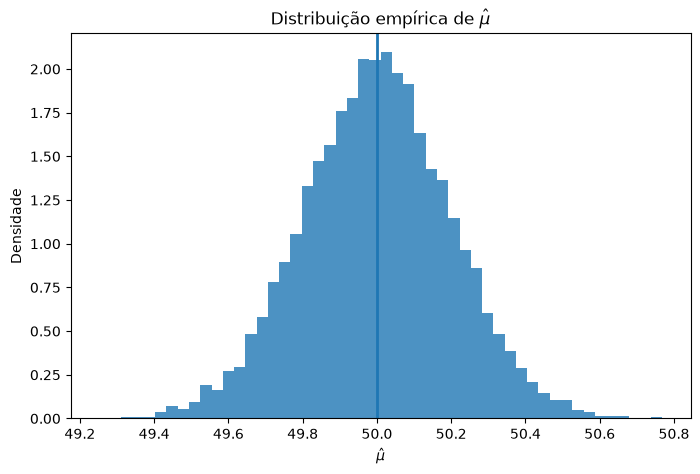

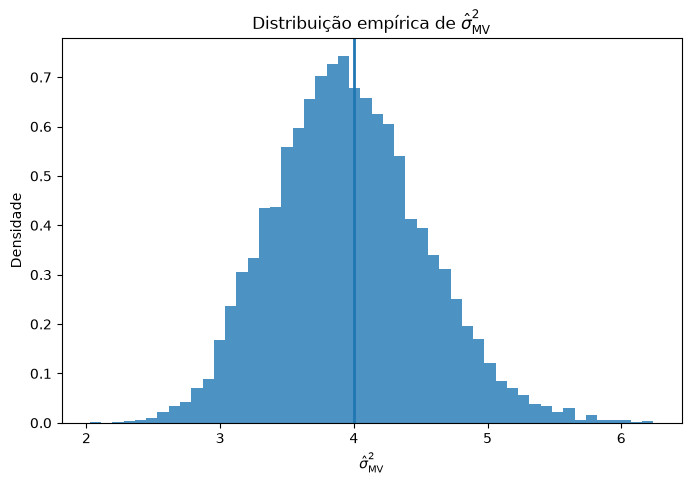

E[mu_hat] empírico      = 50.000195
E[sigma^2_hat] empírico = 3.964388

Viés empírico de mu_hat      = 0.000195
Viés empírico de sigma^2_hat = -0.035612

Var(mu_hat) empírica      = 0.039474
Var(sigma^2_hat) empírica = 0.317315

EQM(mu_hat) empírico      = 0.039474
EQM(sigma^2_hat) empírico = 0.318583

Estimador de mu
EQM direto         = 0.039474
Variância + viés^2 = 0.039474

Estimador de sigma^2
EQM direto         = 0.318583
Variância + viés^2 = 0.318583

E[mu_hat] teórico = 50.000000   viés = 0.000000   Var = 0.040000   EQM = 0.040000
E[sigma^2_hat] teórico = 3.960000   viés = -0.040000   Var = 0.316800   EQM = 0.318400


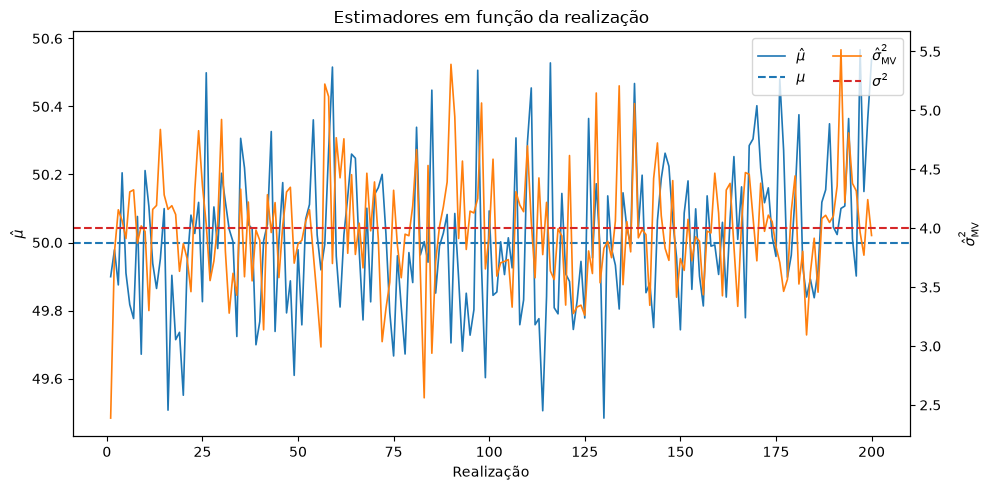


Estabilização aproximada de mu_hat: n = 56
Estabilização aproximada de sigma^2_hat: n = 1403


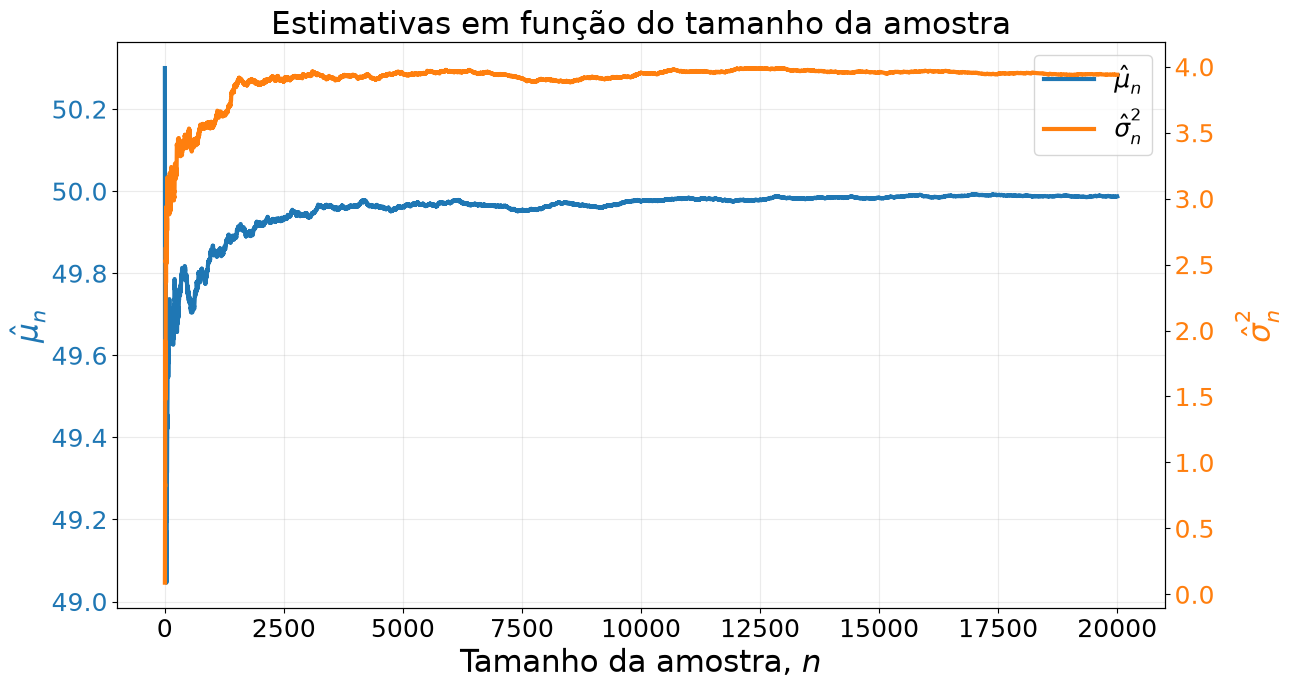

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros verdadeiros
mu = 50
sigma2 = 4
sigma = np.sqrt(sigma2)

# Parâmetros da simulação
n = 100
r = 10_000

# Semente para reprodutibilidade
rng = np.random.default_rng(42)

amostras = rng.normal(loc=mu, scale=sigma, size=(r, n))
print("Dimensão da matriz de amostras:", amostras.shape)

mu_hat = np.mean(amostras, axis=1)
sigma2_hat = np.var(amostras, axis=1, ddof=0)

plt.figure(figsize=(8, 5))
plt.hist(mu_hat, bins=50, density=True, alpha=0.8)
plt.axvline(mu, linewidth=2)
plt.xlabel(r"$\hat{\mu}$")
plt.ylabel("Densidade")
plt.title(r"Distribuição empírica de $\hat{\mu}$")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sigma2_hat, bins=50, density=True, alpha=0.8)
plt.axvline(sigma2, linewidth=2)
plt.xlabel(r"$\hat{\sigma}^2_{\mathrm{MV}}$")
plt.ylabel("Densidade")
plt.title(r"Distribuição empírica de $\hat{\sigma}^2_{\mathrm{MV}}$")
plt.show()

# Valor esperado empírico
E_mu_hat = np.mean(mu_hat)
E_sigma2_hat = np.mean(sigma2_hat)
print(f"E[mu_hat] empírico      = {E_mu_hat:.6f}")
print(f"E[sigma^2_hat] empírico = {E_sigma2_hat:.6f}")

# Viés empírico
bias_mu_hat = E_mu_hat - mu
bias_sigma2_hat = E_sigma2_hat - sigma2
print(f"\nViés empírico de mu_hat      = {bias_mu_hat:.6f}")
print(f"Viés empírico de sigma^2_hat = {bias_sigma2_hat:.6f}")

# Variância empírica
var_mu_hat = np.var(mu_hat, ddof=0)
var_sigma2_hat = np.var(sigma2_hat, ddof=0)
print(f"\nVar(mu_hat) empírica      = {var_mu_hat:.6f}")
print(f"Var(sigma^2_hat) empírica = {var_sigma2_hat:.6f}")

# Erro quadrático médio
eqm_mu_hat = np.mean((mu_hat - mu)**2)
eqm_sigma2_hat = np.mean((sigma2_hat - sigma2)**2)
print(f"\nEQM(mu_hat) empírico      = {eqm_mu_hat:.6f}")
print(f"EQM(sigma^2_hat) empírico = {eqm_sigma2_hat:.6f}")

# Verificação da decomposição do EQM
print("\nEstimador de mu")
print(f"EQM direto         = {eqm_mu_hat:.6f}")
print(f"Variância + viés^2 = {var_mu_hat + bias_mu_hat**2:.6f}")
print("\nEstimador de sigma^2")
print(f"EQM direto         = {eqm_sigma2_hat:.6f}")
print(f"Variância + viés^2 = {var_sigma2_hat + bias_sigma2_hat**2:.6f}")

# Resultados teóricos da Seção 2.1
E_mu_teorico = mu
bias_mu_teorico = 0
var_mu_teorico = sigma2 / n
eqm_mu_teorico = var_mu_teorico
print(f"\nE[mu_hat] teórico = {E_mu_teorico:.6f}   viés = {bias_mu_teorico:.6f}   "
      f"Var = {var_mu_teorico:.6f}   EQM = {eqm_mu_teorico:.6f}")

E_sigma2_teorico = ((n - 1) / n) * sigma2
bias_sigma2_teorico = -sigma2 / n
var_sigma2_teorico = (2 * (n - 1) / n**2) * sigma2**2
eqm_sigma2_teorico = var_sigma2_teorico + bias_sigma2_teorico**2
print(f"E[sigma^2_hat] teórico = {E_sigma2_teorico:.6f}   viés = {bias_sigma2_teorico:.6f}   "
      f"Var = {var_sigma2_teorico:.6f}   EQM = {eqm_sigma2_teorico:.6f}")

# Evolução dos estimadores ao longo das realizações
r_plot = 200
realizacoes = np.arange(1, r_plot + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(realizacoes, mu_hat[:r_plot], linewidth=1.2, label=r"$\hat{\mu}$")
ax1.axhline(mu, linestyle="--", linewidth=1.5, label=r"$\mu$")
ax1.set_xlabel("Realização")
ax1.set_ylabel(r"$\hat{\mu}$")

ax2 = ax1.twinx()
ax2.plot(realizacoes, sigma2_hat[:r_plot], color="tab:orange", linewidth=1.2,
         label=r"$\hat{\sigma}^2_{\mathrm{MV}}$")
ax2.axhline(sigma2, color="tab:red", linestyle="--", linewidth=1.5, label=r"$\sigma^2$")
ax2.set_ylabel(r"$\hat{\sigma}^2_{\mathrm{MV}}$", labelpad=12)

linhas = ax1.get_lines() + ax2.get_lines()
ax1.legend(linhas, [linha.get_label() for linha in linhas], loc="upper right", ncol=2)
plt.title("Estimadores em função da realização")
plt.tight_layout()
plt.show()

# Estimativas em função do tamanho da amostra: uma única realização longa
n_max = 20_000
X = np.random.default_rng(7).normal(loc=mu, scale=sigma, size=n_max)
n_values = np.arange(2, n_max + 1)
mu_hat_n = np.cumsum(X)[1:] / n_values
sigma2_hat_n = np.cumsum(X**2)[1:] / n_values - mu_hat_n**2

# Critérios de estabilização
tol_mu = 0.01       # 1% em torno de mu
tol_sigma2 = 0.05   # 5% em torno de sigma^2

def ponto_estabilizacao(estimativas, valor_real, tolerancia, n_values):
    erro_relativo = np.abs(estimativas - valor_real) / np.abs(valor_real)

    # Primeiro n a partir do qual todas as estimativas seguintes
    # permanecem dentro da tolerância
    for k in range(len(estimativas)):
        if np.all(erro_relativo[k:] <= tolerancia):
            return n_values[k]

    return None

n_estab_mu = ponto_estabilizacao(mu_hat_n, mu, tol_mu, n_values)
n_estab_sigma2 = ponto_estabilizacao(sigma2_hat_n, sigma2, tol_sigma2, n_values)

print(f"\nEstabilização aproximada de mu_hat: n = {n_estab_mu}")
print(f"Estabilização aproximada de sigma^2_hat: n = {n_estab_sigma2}")

fig, ax1 = plt.subplots(figsize=(13, 7))

ax1.plot(n_values, mu_hat_n, linewidth=3, color="tab:blue", label=r"$\hat{\mu}_n$")
ax1.set_xlabel(r"Tamanho da amostra, $n$", fontsize=22)
ax1.set_ylabel(r"$\hat{\mu}_n$", fontsize=22, color="tab:blue")
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18, labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(n_values, sigma2_hat_n, linewidth=3, color="tab:orange", label=r"$\hat{\sigma}_n^2$")
ax2.set_ylabel(r"$\hat{\sigma}_n^2$", fontsize=22, color="tab:orange", labelpad=14)
ax2.tick_params(axis="y", labelsize=18, labelcolor="tab:orange")

linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, labels1 + labels2, loc="upper right", fontsize=18)

ax1.set_title(r"Estimativas em função do tamanho da amostra", fontsize=22)
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Empírico e teórico coincidem em quatro casas: $\hat{\mu}$ tem viés de $2\times10^{-4}$ contra o zero
previsto, e $\hat{\sigma}^2_{\mathrm{MV}}$ tem viés de $-0{,}0356$ contra $-0{,}04$. Nos histogramas, a
linha vertical do valor verdadeiro cai no centro no caso de $\hat{\mu}$ e ligeiramente à direita do
centro no caso de $\hat{\sigma}^2_{\mathrm{MV}}$, que é o viés visto graficamente. A decomposição
$\mathrm{EQM} = b^2 + \operatorname{Var}$ fecha nas seis casas impressas.

O gráfico por realização mostra a mesma dispersão que a tabela resume, sem tendência com o índice da
realização. Já as curvas em função de $n$ convergem em ritmos diferentes: $\hat{\mu}_n$ entra na faixa
de $1\%$ em $n = 56$ e $\hat{\sigma}^2_n$ só entra na faixa de $5\%$ em $n = 1403$. O viés
$-\sigma^2/n$ vale $-0{,}04$ em $n = 100$ e $-0{,}0002$ em $n = 20000$, portanto já é desprezível
diante da flutuação aleatória bem antes do fim do gráfico.

---

## Exercício 1 - Potência ativa de um gerador eólico

A velocidade do vento $u$ é descrita por uma Weibull de parâmetros de forma $k > 0$ e de escala
$\lambda > 0$:

$$
f_U(u) = \frac{k}{\lambda}\left(\frac{u}{\lambda}\right)^{k-1}
\exp\!\left[ -\left(\frac{u}{\lambda}\right)^{k} \right], \qquad u \ge 0 ,
$$

e a potência mecânica extraída por uma turbina de área varrida $A = \pi (D/2)^2$ é
$P(u) = \tfrac{1}{2} C_p \rho A u^3$. Como a velocidade é aleatória, a grandeza de interesse é

$$
\mathbb{E}[P] = \tfrac{1}{2}\, C_p\, \rho\, A \int_0^{\infty} u^3 f_U(u)\, du ,
$$

com $\rho = 1{,}225\ \mathrm{kg/m^3}$, $C_p = 0{,}40$ (dentro do limite de Betz) e $D = 90$ m, de onde
$A = \pi \cdot 45^2 = 6361{,}73\ \mathrm{m^2}$. O enunciado anuncia $n = 48$ medições, mas a Tabela 1
traz nove linhas de oito valores; adotam-se as $n = 72$ velocidades efetivamente tabeladas.

### a) Função de verossimilhança e log-verossimilhança

$$
L(k, \lambda) = \prod_{i=1}^{n} \frac{k}{\lambda}\left(\frac{u_i}{\lambda}\right)^{k-1}
\exp\!\left[ -\left(\frac{u_i}{\lambda}\right)^{k} \right]
= \left(\frac{k}{\lambda}\right)^{n}
\left( \prod_{i=1}^{n} \frac{u_i}{\lambda} \right)^{k-1}
\exp\!\left[ -\sum_{i=1}^{n} \left(\frac{u_i}{\lambda}\right)^{k} \right].
$$

Tomando o logaritmo e agrupando os termos em $\ln \lambda$:

$$
\boxed{\;
\ell(k,\lambda) = n \ln k - n k \ln \lambda + (k-1)\sum_{i=1}^{n} \ln u_i
- \lambda^{-k} \sum_{i=1}^{n} u_i^{\,k}
\;}
$$

### b) Equações de verossimilhança

**Derivada em $\lambda$.** Apenas o segundo e o quarto termos dependem de $\lambda$:

$$
\frac{\partial \ell}{\partial \lambda}
= -\frac{nk}{\lambda} + k\,\lambda^{-k-1} \sum_{i=1}^{n} u_i^{\,k} = 0 .
$$

Multiplicando por $\lambda^{k+1}/k$, vem $n \lambda^{k} = \sum_i u_i^{k}$, ou seja,

$$
\boxed{\;\hat{\lambda} = \left( \frac{1}{n}\sum_{i=1}^{n} u_i^{\,k} \right)^{1/k}\;}
$$

**Derivada em $k$.** Usando $\dfrac{\partial}{\partial k}(u_i/\lambda)^{k} = (u_i/\lambda)^{k}\ln(u_i/\lambda)$,

$$
\frac{\partial \ell}{\partial k}
= \frac{n}{k} - n \ln \lambda + \sum_{i=1}^{n} \ln u_i
- \sum_{i=1}^{n} \left(\frac{u_i}{\lambda}\right)^{k} \ln\!\left(\frac{u_i}{\lambda}\right) = 0 .
$$

Abrindo o último somatório como
$\lambda^{-k}\sum_i u_i^{k}\ln u_i - \ln\lambda\,\lambda^{-k}\sum_i u_i^{k}$ e substituindo
$\lambda^{-k} = n / \sum_j u_j^{k}$ vindo da equação anterior, o termo $n\ln\lambda$ cancela com o
segundo termo. Dividindo o que resta por $n$, obtém-se uma equação em uma única incógnita:

$$
\boxed{\;
g(k) = \frac{\sum_{i=1}^{n} u_i^{\,k}\ln u_i}{\sum_{i=1}^{n} u_i^{\,k}}
- \frac{1}{k} - \frac{1}{n}\sum_{i=1}^{n}\ln u_i = 0
\;}
$$

### c) Solução numérica por bissecção

O intervalo de busca vem do comportamento de $g$ nos extremos. Quando $k \to 0^{+}$, o termo $-1/k$
domina e $g \to -\infty$. Quando $k \to \infty$, a razão $\sum u_i^k \ln u_i / \sum u_i^k$ tende a
$\ln u_{\max} = \ln 16{,}4 = 2{,}797$ e $1/k \to 0$, de modo que $g$ tende à diferença entre
$\ln u_{\max}$ e a média de $\ln u_i$, que é positiva. Logo existe raiz, e $[0{,}5;\ 10]$ é um
intervalo de troca de sinal seguro.

### d) Substituição do limite superior por um valor finito

Com a mudança de variável $t = (u/\lambda)^k$, tem-se $u = \lambda t^{1/k}$ e $f_U(u)\,du = e^{-t}\,dt$,
de modo que

$$
\int_{u_{\max}}^{\infty} u^3 f_U(u)\, du
= \lambda^3 \int_{T}^{\infty} t^{3/k} e^{-t}\, dt,
\qquad
T = \left( \frac{u_{\max}}{\lambda} \right)^{k}.
$$

Escolhendo $u_{\max}$ como o quantil de ordem $p$ da Weibull ajustada,
$u_{\max} = \lambda [-\ln(1-p)]^{1/k}$, resulta $T = -\ln(1-p)$ e $e^{-T} = 1-p$. Como
$3/\hat{k} = 1{,}488 < 2$ e $T > 1$, vale $t^{3/k} \le t^2$ no domínio de integração, e

$$
\int_{T}^{\infty} t^{2} e^{-t}\, dt = \left[ -e^{-t}(t^2 + 2t + 2) \right]_{T}^{\infty}
= (T^2 + 2T + 2)\,e^{-T}
\qquad \Longrightarrow \qquad
\int_{u_{\max}}^{\infty} u^3 f_U\, du \le \lambda^3 (T^2 + 2T + 2)(1-p) .
$$

Com $p = 1 - 10^{-6}$ tem-se $T = 13{,}8155$, $T^2 + 2T + 2 = 220{,}5$ e $\hat{\lambda}^3 = 468{,}99$,
o que dá uma cota de $0{,}103$. O item (e) calcula a integral truncada em $618{,}04$, contra a qual
essa cota vale $1{,}7\times10^{-4}$, ou seja, o truncamento fica duas ordens de grandeza abaixo do
erro das próprias quadraturas.

### e) Potência esperada por três métodos de quadratura

Com $h(u) = u^3 f_U(u)$ sobre $[0, u_{\max}]$, $m$ subintervalos de largura $h = u_{\max}/m$,
$y_j = h(u_j)$ e $u_j = j\,h$:

$$
\text{Trapézio:} \quad
h\left[ \frac{y_0}{2} + \sum_{j=1}^{m-1} y_j + \frac{y_m}{2} \right],
\qquad
\text{Simpson:} \quad
\frac{h}{3}
\left[ y_0 + 4\!\!\sum_{j \text{ ímpar}}\!\! y_j + 2\!\!\sum_{j \text{ par},\, j \ne 0, m}\!\! y_j + y_m \right],
$$

$$
\text{Gauss-Legendre:} \quad
\frac{u_{\max}}{2} \sum_{j=1}^{m} w_j\, h\!\left( \frac{u_{\max}}{2}(t_j + 1) \right),
$$

esta última com nós $t_j$ e pesos $w_j$ tabelados em $[-1,1]$ e a mudança linear de variável
$u = \frac{u_{\max}}{2}(t+1)$, cujo jacobiano é $u_{\max}/2$. As três regras são comparadas entre si,
refinando $m$ até que os valores parem de mudar.

n = 72   media amostral = 6.8806 m/s
k_hat = 2.016624   lambda_hat = 7.769389 m/s   resíduo g(k_hat) = 2.22e-16


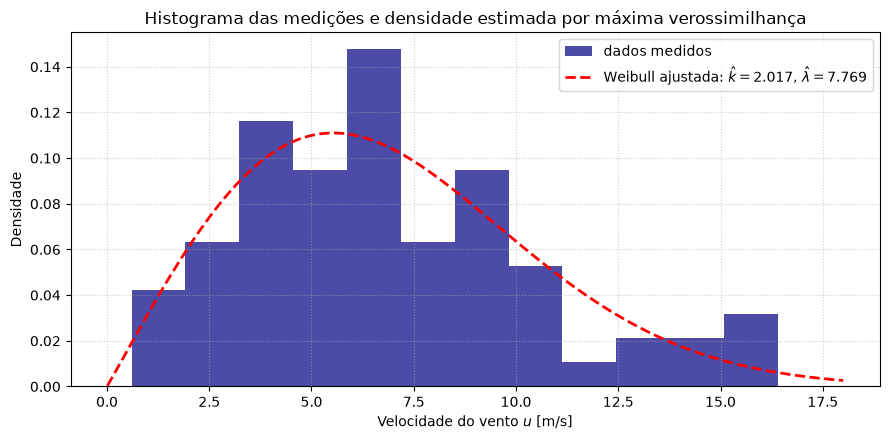


           p   u_max [m/s]         T   cota da cauda
        0.99       16.5682    4.6052      152.035811
       0.999       20.2580    6.9078       29.795945
      0.9999       23.3642    9.2103        4.936135
     0.99999       26.0979   11.5129        0.738998
    0.999999       28.5673   13.8155        0.103411

u_max = 28.5673 m/s

     m        trapézio         Simpson    Gauss-Legendre
    10      618.030075      618.062936        618.042132
    20      618.039867      618.043131        618.043058
    40      618.042255      618.043051        618.043058
    80      618.042857      618.043058        618.043058
   160      618.043008      618.043058        618.043058
   320      618.043046      618.043058        618.043058

A = pi*(D/2)^2 = 6361.73 m^2

método                 m        E[u^3]     E[P] [kW]
Trapézio             320    618.043046       963.296
Simpson               80    618.043058       963.296
Gauss-Legendre        20    618.043058       963.296

cota da cauda de

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Tabela 1: velocidades do vento medidas, em m/s
u = np.array([
    0.6,  1.0,  1.4,  1.9,  2.2,  2.5,  2.7,  2.9,
    3.0,  3.1,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,
    3.9,  4.0,  4.1,  4.3,  4.5,  4.8,  4.9,  5.2,
    5.3,  5.3,  5.3,  5.4,  5.6,  5.8,  5.9,  6.0,
    6.1,  6.2,  6.2,  6.3,  6.3,  6.4,  6.5,  6.6,
    6.6,  6.8,  6.9,  7.1,  7.5,  7.8,  8.0,  8.1,
    8.2,  8.4,  8.5,  8.6,  8.7,  8.8,  9.0,  9.1,
    9.3,  9.4,  9.6,  9.9, 10.0, 10.4, 10.8, 11.1,
    11.7, 12.6, 13.0, 13.8, 14.8, 15.1, 15.9, 16.4])

# b) equação de verossimilhança em k
def g(k):
    uk = u**k
    return np.sum(uk * np.log(u)) / np.sum(uk) - 1 / k - np.mean(np.log(u))

# c) bissecção no intervalo de troca de sinal
a, b = 0.5, 10.0
for _ in range(60):
    m = 0.5 * (a + b)
    if g(a) * g(m) <= 0:
        b = m
    else:
        a = m

k_hat = 0.5 * (a + b)
lambda_hat = np.mean(u**k_hat)**(1 / k_hat)
print(f"n = {u.size}   media amostral = {u.mean():.4f} m/s")
print(f"k_hat = {k_hat:.6f}   lambda_hat = {lambda_hat:.6f} m/s   resíduo g(k_hat) = {g(k_hat):.2e}")

def f_weibull(x):
    return (k_hat / lambda_hat) * (x / lambda_hat)**(k_hat - 1) * np.exp(-(x / lambda_hat)**k_hat)

grade = np.linspace(0.01, 18, 400)
plt.figure(figsize=(9, 4.5))
plt.hist(u, bins=12, density=True, color="navy", alpha=0.7, label="dados medidos")
plt.plot(grade, f_weibull(grade), color="red", linestyle="--", linewidth=2,
         label=rf"Weibull ajustada: $\hat{{k}} = {k_hat:.3f}$, $\hat{{\lambda}} = {lambda_hat:.3f}$")
plt.xlabel("Velocidade do vento $u$ [m/s]")
plt.ylabel("Densidade")
plt.title("Histograma das medições e densidade estimada por máxima verossimilhança")
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# d) cota da cauda descartada ao truncar a integral em u_max
def quantil(p):
    return lambda_hat * (-np.log(1 - p))**(1 / k_hat)

print(f"\n{'p':>12}{'u_max [m/s]':>14}{'T':>10}{'cota da cauda':>16}")
for p in [0.99, 0.999, 0.9999, 0.99999, 0.999999]:
    T = -np.log(1 - p)
    print(f"{p:>12}{quantil(p):>14.4f}{T:>10.4f}"
          f"{lambda_hat**3 * (T**2 + 2 * T + 2) * (1 - p):>16.6f}")

u_max = quantil(0.999999)
T_max = -np.log(1 - 0.999999)
cota = lambda_hat**3 * (T_max**2 + 2 * T_max + 2) * 1e-6

# e) as três regras de quadratura
def integrando(x):
    return x**3 * f_weibull(x)

def trapezio(m):
    y = integrando(np.linspace(0, u_max, m + 1))
    return (u_max / m) * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])

def simpson(m):
    y = integrando(np.linspace(0, u_max, m + 1))
    return (u_max / m) / 3 * (y[0] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum() + y[-1])

def gauss_legendre(m):
    t, w = np.polynomial.legendre.leggauss(m)
    return 0.5 * u_max * np.sum(w * integrando(0.5 * u_max * (t + 1)))

print(f"\nu_max = {u_max:.4f} m/s\n")
print(f"{'m':>6}{'trapézio':>16}{'Simpson':>16}{'Gauss-Legendre':>18}")
for m in [10, 20, 40, 80, 160, 320]:
    print(f"{m:>6}{trapezio(m):>16.6f}{simpson(m):>16.6f}{gauss_legendre(m):>18.6f}")

rho, Cp, D = 1.225, 0.40, 90.0
A_rotor = pi * (D / 2)**2
print(f"\nA = pi*(D/2)^2 = {A_rotor:.2f} m^2\n")
print(f"{'método':<18}{'m':>6}{'E[u^3]':>14}{'E[P] [kW]':>14}")
for nome, m, valor in [("Trapézio", 320, trapezio(320)), ("Simpson", 80, simpson(80)),
                       ("Gauss-Legendre", 20, gauss_legendre(20))]:
    print(f"{nome:<18}{m:>6}{valor:>14.6f}{0.5 * Cp * rho * A_rotor * valor / 1e3:>14.3f}")

print(f"\ncota da cauda descartada = {cota:.6f}, ou {cota / gauss_legendre(20):.1e} do valor calculado")

A densidade ajustada tem $\hat{k} = 2{,}0166$ e $\hat{\lambda} = 7{,}7694$ m/s. A cota da cauda em
$p = 1 - 10^{-6}$ fica em $0{,}103$, contra $618{,}04$ calculados, o que confirma o limite
$u_{\max} = 28{,}57$ m/s adotado.

Os três métodos convergem para $618{,}0430$, e

$$
\mathbb{E}[P] = \tfrac{1}{2} \cdot 0{,}40 \cdot 1{,}225 \cdot 6361{,}73 \cdot 618{,}04
= 963{,}3\ \mathrm{kW}.
$$

O que separa os métodos é o custo. Na tabela de refinamento, o trapézio ainda muda de valor entre
$m = 160$ e $m = 320$, enquanto Simpson repete o mesmo resultado a partir de $m = 80$ e
Gauss-Legendre a partir de $m = 20$ nós.

---

## Exercício 2 - Sinal senoidal em AWGN

$$
x[n] = A\cos\!\left( 2\pi f n T_s + \phi \right) + w[n],
\qquad n = 0, 1, \ldots, N-1,
$$

com $A$ e $\phi$ conhecidos, $w[n] \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, \sigma^2)$,
$T_s = 1/f_s$ e $f$ a estimar.

### a) Geração do sinal observado

Com $f_s = 1920$ Hz e $f = 60$ Hz há $1920/60 = 32$ amostras por período, de modo que
$N = \text{Períodos} \cdot 32 = 128$ cobre os 4 períodos iniciais. A amplitude é
$A = 127\sqrt{2} = 179{,}605$ V, a fase é $\phi = 60^{\circ}$ e o nível de ruído inicial é
$\sigma = 0{,}05 \cdot 179{,}605 = 8{,}98$ V, que coincide com o valor do enunciado.

### b) Função de verossimilhança

Cada observação é $X[n] \sim \mathcal{N}(A\cos(2\pi f n T_s + \phi),\ \sigma^2)$, e as $N$ observações
são independentes porque o ruído é branco. Logo

$$
\boxed{\;
f_{\mathbf{X}}(\mathbf{x} \mid f)
= \frac{1}{(2\pi\sigma^2)^{N/2}}
\exp\!\left\{ -\frac{1}{2\sigma^2} \sum_{n=0}^{N-1}
\left[ x[n] - A\cos(2\pi f n T_s + \phi) \right]^2 \right\}
\;}
$$

$$
\ell(f) = -\frac{N}{2}\ln\!\left( 2\pi\sigma^2 \right)
- \frac{1}{2\sigma^2} \sum_{n=0}^{N-1} \left[ x[n] - A\cos(2\pi f n T_s + \phi) \right]^2 .
$$

### c) Equivalência com a minimização de $J(f)$ e gradiente descendente

Em $\ell(f)$ o primeiro termo não depende de $f$ e o segundo é $-J(f)/(2\sigma^2)$, com

$$
J(f) = \sum_{n=0}^{N-1} \left[ x[n] - A\cos(2\pi f n T_s + \phi) \right]^2 .
$$

Como $-1/(2\sigma^2) < 0$ é constante, $\ell(f)$ é função afim decrescente de $J(f)$, e portanto
$\arg\max_f \ell(f) = \arg\min_f J(f)$.

**Gradiente.** Com $\theta_n(f) = 2\pi f n T_s + \phi$ e $\mathrm{d}\theta_n/\mathrm{d}f = 2\pi n T_s$,
a regra da cadeia dá

$$
\frac{\mathrm{d}J}{\mathrm{d}f}
= \sum_{n=0}^{N-1} 2\left[ x[n] - A\cos\theta_n \right] \cdot A\sin\theta_n \cdot 2\pi n T_s
\qquad \Longrightarrow \qquad
\boxed{\;
\frac{\mathrm{d}J(f)}{\mathrm{d}f}
= 4\pi A T_s \sum_{n=0}^{N-1} n \left[ x[n] - A\cos\theta_n \right] \sin\theta_n
\;}
$$

e a iteração é $f^{(k+1)} = f^{(k)} - \eta\, \mathrm{d}J/\mathrm{d}f \big|_{f = f^{(k)}}$, com
$f^{(0)} = 58$ Hz.

**Escolha do passo.** O enunciado não fixa $\eta$, que foi ajustado numericamente. O gradiente vale
$4{,}3\times10^{5}$ em $f = 58$ Hz, de modo que $\eta = 10^{-5}$ produz um primeiro passo maior que a
própria distância até o mínimo e a iteração se afasta em vez de convergir, enquanto $\eta = 10^{-7}$
ainda não alcança $60$ Hz em $200$ iterações. Adota-se $\eta = 10^{-6}$ com $200$ iterações, e a
convergência é avaliada nos gráficos de $f^{(k)}$ e $J(f^{(k)})$.

### d) Comportamento do estimador em função do nível de ruído

Para cada $\delta \in \{10, 20, 50, 100\}\%$, com $\sigma = \frac{\delta}{100}A$, geram-se $M = 500$
realizações independentes e aplica-se o gradiente descendente a cada uma, obtendo
$\hat{f}^{(1)}, \ldots, \hat{f}^{(M)}$. As duas grandezas pedidas são

$$
\mathbb{E}[\hat{f}] \approx \frac{1}{M}\sum_{m=1}^{M} \hat{f}^{(m)},
\qquad
\operatorname{Var}(\hat{f}) \approx \frac{1}{M}\sum_{m=1}^{M}
\left( \hat{f}^{(m)} - \overline{\hat{f}} \right)^2 ,
$$

que são o valor esperado e a variância empíricos da Aula 3 aplicados ao estimador $\hat{f}$. Como o
único parâmetro que muda entre as quatro varreduras é $\sigma$, a tabela compara cada variância com a
obtida em $\delta = 10\%$, de modo a exibir diretamente como ela escala com o nível de ruído.

A = 179.6051 V   fs = 1920.0 Hz   N = 128   duração = 0.066667 s   sigma = 8.9803 V


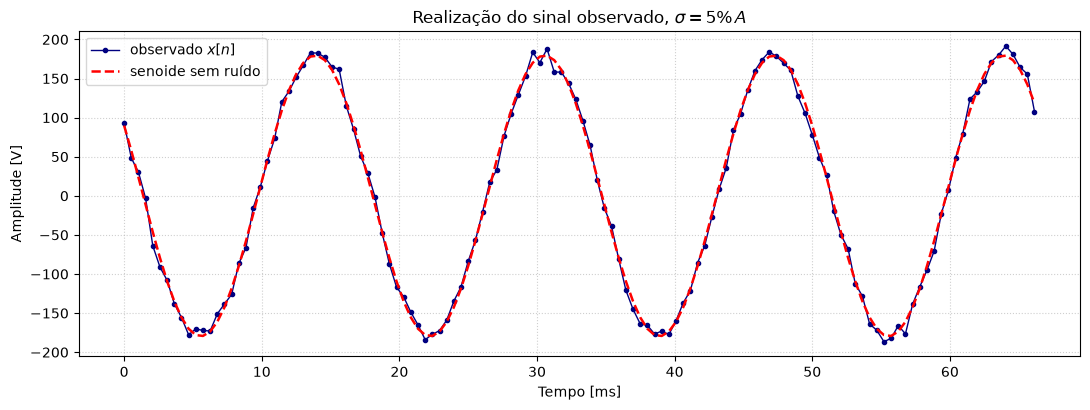

máximo da log-verossimilhança na grade: f = 60.0000 Hz


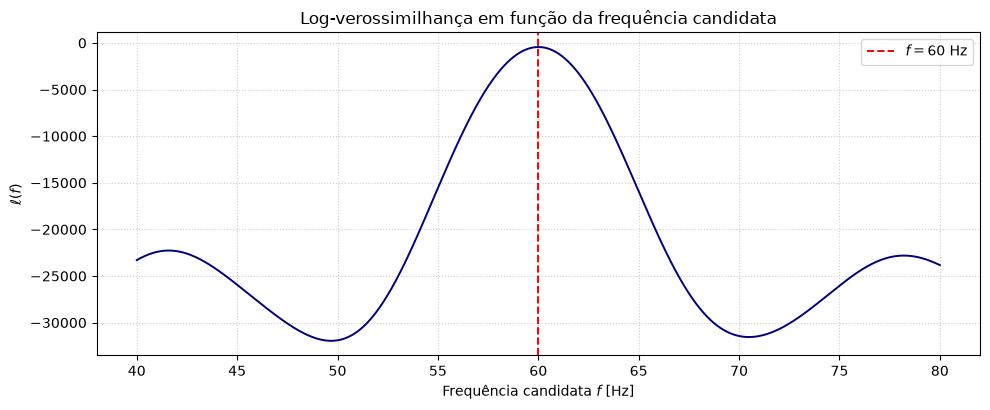


dJ/df em 58 Hz: analítico = -431225.5618   numérico = -431225.5603
f estimado = 60.005841 Hz   erro = +0.005841 Hz
J inicial = 448941.66   J final = 6536.62   energia do ruído = 6540.50   N*sigma^2 = 10322.56


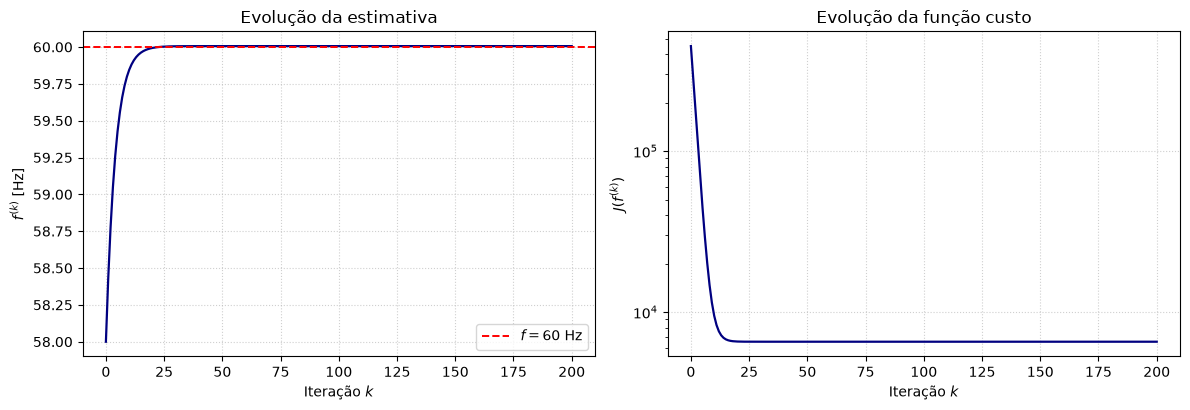


  delta   sigma [V]   E[f] [Hz]      Var(f)  Var/Var(10%)  (delta/10)^2
    10%      17.961    59.99994     0.00317          1.00          1.00
    20%      35.921    60.00028     0.01198          3.78          4.00
    50%      89.803    59.99307     0.07424         23.40         25.00
   100%     179.605    60.04236     0.32732        103.17        100.00


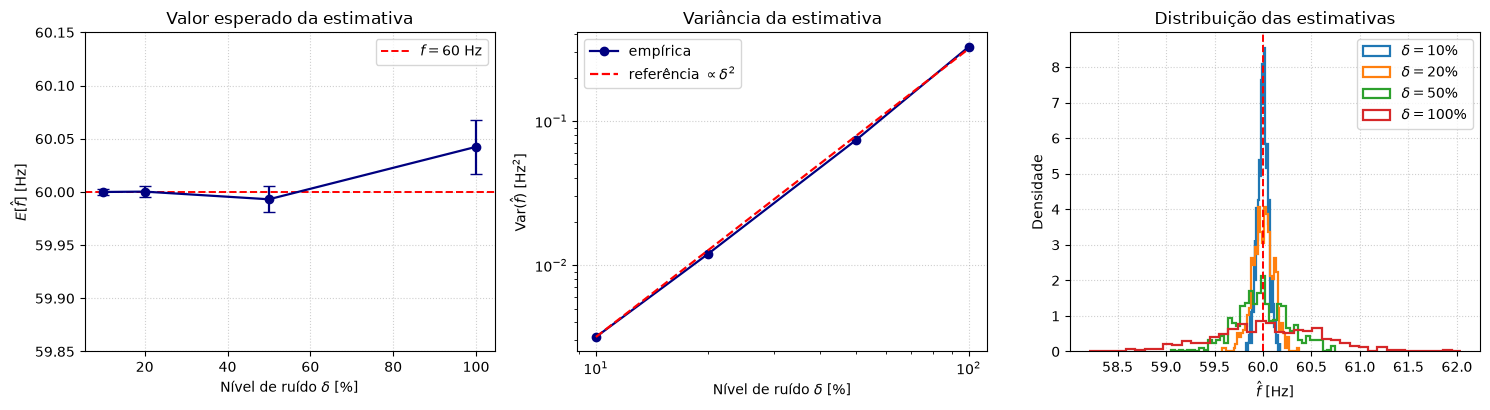

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# a) parâmetros do sinal e da aquisição
A = 127 * np.sqrt(2)
f_real = 60.0
phi = np.deg2rad(60.0)
fs = 1920.0
Ts = 1 / fs
N = 4 * 32
n_idx = np.arange(N)
sigma_w = 0.05 * A

s = A * np.cos(2 * np.pi * f_real * n_idx * Ts + phi)
x = s + np.random.default_rng(42).normal(0, sigma_w, N)
print(f"A = {A:.4f} V   fs = {fs} Hz   N = {N}   duração = {N * Ts:.6f} s   sigma = {sigma_w:.4f} V")

plt.figure(figsize=(11, 4.2))
plt.plot(n_idx * Ts * 1e3, x, color="navy", linewidth=1.0, marker="o", markersize=3,
         label=r"observado $x[n]$")
plt.plot(n_idx * Ts * 1e3, s, color="red", linestyle="--", linewidth=1.8, label="senoide sem ruído")
plt.xlabel("Tempo [ms]")
plt.ylabel("Amplitude [V]")
plt.title(r"Realização do sinal observado, $\sigma = 5\%\,A$")
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# b) log-verossimilhança em função de frequências candidatas
def J(f, sinal):
    return np.sum((sinal - A * np.cos(2 * np.pi * f * n_idx * Ts + phi))**2)

def log_veros(f, sinal):
    return -N / 2 * np.log(2 * np.pi * sigma_w**2) - J(f, sinal) / (2 * sigma_w**2)

candidatas = np.linspace(40, 80, 2001)
ell = np.array([log_veros(f, x) for f in candidatas])
print(f"máximo da log-verossimilhança na grade: f = {candidatas[np.argmax(ell)]:.4f} Hz")

plt.figure(figsize=(10, 4.2))
plt.plot(candidatas, ell, color="navy", linewidth=1.4)
plt.axvline(f_real, color="red", linestyle="--", linewidth=1.4, label=r"$f = 60$ Hz")
plt.xlabel("Frequência candidata $f$ [Hz]")
plt.ylabel(r"$\ell(f)$")
plt.title("Log-verossimilhança em função da frequência candidata")
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# c) gradiente analítico e gradiente descendente
def grad_J(f, sinal):
    theta = 2 * np.pi * f * n_idx * Ts + phi
    return 4 * np.pi * A * Ts * np.sum(n_idx * (sinal - A * np.cos(theta)) * np.sin(theta))

def descida(sinal, eta=1e-6, n_iter=200, f0=58.0):
    f = f0
    historico = np.empty(n_iter + 1)
    historico[0] = f
    for k in range(n_iter):
        f = f - eta * grad_J(f, sinal)
        historico[k + 1] = f
    return historico

h = 1e-6
print(f"\ndJ/df em 58 Hz: analítico = {grad_J(58.0, x):.4f}   "
      f"numérico = {(J(58 + h, x) - J(58 - h, x)) / (2 * h):.4f}")

historico = descida(x)
custo = np.array([J(f, x) for f in historico])
print(f"f estimado = {historico[-1]:.6f} Hz   erro = {historico[-1] - f_real:+.6f} Hz")
print(f"J inicial = {custo[0]:.2f}   J final = {custo[-1]:.2f}   "
      f"energia do ruído = {np.sum((x - s)**2):.2f}   N*sigma^2 = {N * sigma_w**2:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(historico, color="navy", linewidth=1.6)
ax[0].axhline(f_real, color="red", linestyle="--", linewidth=1.4, label=r"$f = 60$ Hz")
ax[0].set_ylabel(r"$f^{(k)}$ [Hz]")
ax[0].set_title("Evolução da estimativa")
ax[0].legend()
ax[1].semilogy(custo, color="navy", linewidth=1.6)
ax[1].set_ylabel(r"$J(f^{(k)})$")
ax[1].set_title("Evolução da função custo")
for eixo in ax:
    eixo.set_xlabel("Iteração $k$")
    eixo.grid(linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# d) varredura do nível de ruído
deltas = [10, 20, 50, 100]
M = 500
rng_ruido = np.random.default_rng(42)
estimativas = [np.array([descida(s + rng_ruido.normal(0, d / 100 * A, N))[-1] for _ in range(M)])
               for d in deltas]
var_emp = [e.var(ddof=0) for e in estimativas]

print(f"\n{'delta':>7}{'sigma [V]':>12}{'E[f] [Hz]':>12}{'Var(f)':>12}"
      f"{'Var/Var(10%)':>14}{'(delta/10)^2':>14}")
for j, d in enumerate(deltas):
    print(f"{d:>6}%{d / 100 * A:>12.3f}{estimativas[j].mean():>12.5f}{var_emp[j]:>12.5f}"
          f"{var_emp[j] / var_emp[0]:>14.2f}{(d / 10)**2:>14.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].errorbar(deltas, [e.mean() for e in estimativas],
               yerr=[e.std() / np.sqrt(M) for e in estimativas],
               color="navy", marker="o", capsize=4, linewidth=1.6)
ax[0].axhline(f_real, color="red", linestyle="--", linewidth=1.4, label=r"$f = 60$ Hz")
ax[0].set_ylim(f_real - 0.15, f_real + 0.15)
ax[0].set_xlabel(r"Nível de ruído $\delta$ [%]")
ax[0].set_ylabel(r"$E[\hat{f}]$ [Hz]")
ax[0].set_title("Valor esperado da estimativa")
ax[0].legend()

ax[1].loglog(deltas, var_emp, color="navy", marker="o", linewidth=1.6, label="empírica")
ax[1].loglog(deltas, [var_emp[0] * (d / 10)**2 for d in deltas], color="red", linestyle="--",
             linewidth=1.6, label=r"referência $\propto \delta^2$")
ax[1].set_xlabel(r"Nível de ruído $\delta$ [%]")
ax[1].set_ylabel(r"$\mathrm{Var}(\hat{f})$ [Hz$^2$]")
ax[1].set_title("Variância da estimativa")
ax[1].legend()

for j, d in enumerate(deltas):
    ax[2].hist(estimativas[j], bins=40, density=True, histtype="step", linewidth=1.6,
               label=rf"$\delta = {d}\%$")
ax[2].axvline(f_real, color="red", linestyle="--", linewidth=1.4)
ax[2].set_xlabel(r"$\hat{f}$ [Hz]")
ax[2].set_ylabel("Densidade")
ax[2].set_title("Distribuição das estimativas")
ax[2].legend()

for eixo in ax:
    eixo.grid(linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

A log-verossimilhança tem um único máximo, em $60$ Hz, sem nenhum outro ponto estacionário entre
cerca de $50$ e $70$ Hz, faixa que contém o valor inicial $f^{(0)} = 58$ Hz. O gradiente analítico
confere com a diferença centrada nas sete primeiras casas, e a estimativa alcança a vizinhança de
$60$ Hz em cerca de $20$ iterações.
O custo não vai a zero: seu mínimo é essencialmente a energia do ruído da realização, $6540{,}5$
contra $J(\hat{f}) = 6536{,}6$.

As médias permanecem em $60$ Hz dentro de alguns centésimos, e as barras de erro, iguais ao
desvio-padrão das estimativas dividido por $\sqrt{M}$, mostram que os desvios são da ordem da
incerteza da própria média amostral: não há evidência de viés. A variância vai de $0{,}0032$ a
$0{,}0120$, $0{,}0742$ e $0{,}3273\ \mathrm{Hz^2}$, ou seja, multiplica-se por $3{,}8$, $23{,}4$ e
$103{,}2$ enquanto $\delta$ é multiplicado por $2$, $5$ e $10$. A variância cresce, portanto, com o
quadrado do nível de ruído, e é por isso que a curva empírica acompanha a reta de referência
$\propto \delta^2$ no gráfico central.

No histograma, o desvio-padrão das estimativas vai de $0{,}06$ Hz em $\delta = 10\%$ para $0{,}57$ Hz
em $\delta = 100\%$. Mesmo quando o desvio-padrão do ruído iguala a amplitude do sinal, a distribuição
continua concentrada em torno de $60$ Hz.